# 04 · RUL Regressor
**Goal:** Predict remaining useful life (RUL) from engineered sensor features.

| Section | Content |
|---|---|
| 1 | Data loading & 80/10/10 unit split |
| 2 | Scoring functions & naive baselines |
| 3 | Extended feature engineering (EWMA · interactions · fleet-relative · acceleration) |
| 4 | Hyperparameter search — XGBoost + LightGBM (Optuna, 50 trials each, shared CV) |
| 5 | Model comparison — 2×2 grid: {XGB, LGB} × {all\_37, extended} |
| 6 | Winner analysis — residuals · CI ribbon · feature importance |
| 7 | Save artefacts |

**Input:** `data/processed/FD004_train.parquet`  
**Output:** `models/rul/rul_model.pkl` + quantile bounds + metadata

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.float_format', '{:.4f}'.format)

PROCESSED = Path('../data/processed')
MODELS    = Path('../models')
RUL_DIR   = MODELS / 'rul'
RUL_DIR.mkdir(parents=True, exist_ok=True)

RUL_CAP        = 130
SENSORS        = ['s2','s3','s4','s7','s8','s11','s13','s14','s15']
NORM_COLS      = [f'n_{s}'         for s in SENSORS]
ROLL_MEAN_COLS = [f'roll_mean_{s}' for s in SENSORS]
ROLL_STD_COLS  = [f'roll_std_{s}'  for s in SENSORS]
SLOPE_COLS     = [f'slope_{s}'     for s in SENSORS]
ALL_FEATURES   = NORM_COLS + ROLL_MEAN_COLS + ROLL_STD_COLS + SLOPE_COLS + ['cycle_frac']

# ── ROCm / GPU detection ─────────────────────────────────────────────────────
# XGBoost 3.x uses device='cuda' which routes through HIP on ROCm — no recompile needed.
# LightGBM (PyPI wheel) has no GPU support compiled in; always runs CPU.
os.environ.setdefault('HSA_OVERRIDE_GFX_VERSION', '11.0.0')  # required for gfx1101 (RX 7800 XT)

XGB_DEVICE = 'cpu'
try:
    _r = subprocess.run(['rocm-smi', '--showproductname'],
                        capture_output=True, text=True, timeout=5)
    if _r.returncode == 0 and 'RX 7800' in _r.stdout:
        # Quick smoke-test: does XGBoost actually accept the device?
        _probe = xgb.XGBRegressor(device='cuda', n_estimators=1, random_state=0)
        _probe.fit(np.zeros((4,2)), np.zeros(4))
        XGB_DEVICE = 'cuda'
except Exception as _e:
    print(f'  ROCm probe failed ({_e}) — falling back to CPU')

print(f'XGBoost  {xgb.__version__}  →  device={XGB_DEVICE}')
print(f'LightGBM {lgb.__version__}  →  device=cpu  (PyPI wheel, no GPU support)')
print(f'Base feature set: {len(ALL_FEATURES)} features')

XGBoost  3.2.0  →  device=cuda
LightGBM 4.6.0  →  device=cpu  (PyPI wheel, no GPU support)
Base feature set: 37 features


## 1 · Data Loading & Unit Split

In [2]:
df = pd.read_parquet(PROCESSED / 'FD004_train.parquet')
print(f'Loaded: {df.shape}  —  {df.unit.nunique()} engines')

# Split by engine — never by row (consecutive cycles are highly correlated)
rng   = np.random.default_rng(42)
units = df['unit'].unique()
rng.shuffle(units)

n       = len(units)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

train_units   = units[:n_train]
val_units     = units[n_train:n_train + n_val]
holdout_units = units[n_train + n_val:]

df_train   = df[df.unit.isin(train_units)].copy()
df_val     = df[df.unit.isin(val_units)].copy()
df_holdout = df[df.unit.isin(holdout_units)].copy()

X_train,   y_train   = df_train[ALL_FEATURES].values,   df_train['rul'].to_numpy()
X_val,     y_val     = df_val[ALL_FEATURES].values,     df_val['rul'].to_numpy()
X_holdout, y_holdout = df_holdout[ALL_FEATURES].values, df_holdout['rul'].to_numpy()

print(f'Train:   {len(train_units):3d} engines  {len(df_train):6d} rows')
print(f'Val:     {len(val_units):3d} engines  {len(df_val):6d} rows')
print(f'Holdout: {len(holdout_units):3d} engines  {len(df_holdout):6d} rows')


Loaded: (61249, 42)  —  249 engines
Train:   199 engines   49521 rows
Val:      24 engines    5393 rows
Holdout:  26 engines    6335 rows


## 2 · Scoring Functions & Naive Baselines

In [3]:
def nasa_score(y_true, y_pred):
    """Asymmetric penalty: late predictions (over-estimating RUL) penalised harder.
    d < 0 → predicted too early (over-cautious).
    d > 0 → predicted too late (missed failure) — worse.
    """
    d = np.asarray(y_pred, dtype=float) - np.asarray(y_true, dtype=float)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def evaluate(name, y_true, y_pred):
    pred_arr = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(mean_squared_error(y_true, pred_arr)))
    mae  = float(mean_absolute_error(y_true, pred_arr))
    ns   = nasa_score(y_true, pred_arr)
    print(f'{name:<30s}  RMSE={rmse:7.2f}  MAE={mae:7.2f}  NASA={ns:12.1f}')
    return {'rmse': rmse, 'mae': mae, 'nasa': ns}

print('=== Naive baselines (holdout) — floor any trained model must beat ===')
evaluate('Mean predictor',       y_holdout,
         np.full_like(y_holdout, y_train.mean(), dtype=float))
evaluate('Constant (RUL_CAP/2)', y_holdout,
         np.full_like(y_holdout, RUL_CAP / 2,   dtype=float))


=== Naive baselines (holdout) — floor any trained model must beat ===
Mean predictor                  RMSE=  42.66  MAE=  37.32  NASA=   3985885.9
Constant (RUL_CAP/2)            RMSE=  52.18  MAE=  47.66  NASA=    661614.3


{'rmse': 52.17541447172197,
 'mae': 47.65982636148382,
 'nasa': 661614.2674914321}

## 3 · Extended Feature Engineering

Four families added on top of the base 37:

| Family | Columns | Rationale |
|---|---|---|
| **EWMA** | `ewma_s*` | Exponentially-weighted mean (span=20) weights recent cycles more than simple rolling mean — more sensitive to late-stage degradation acceleration |
| **Interactions** | `cf_x_s*` | `cycle_frac × normalised_sensor` — explicit *degradation × life-stage* encoding, no need for the tree to discover it via two splits |
| **Fleet-relative** | `fleet_dev_s*` | Deviation from fleet mean at the same life fraction — flags outlier engines; baseline fitted on train only, no leakage |
| **Acceleration** | `accel_s*` | Rolling mean of the slope derivative (2nd order) — flags engines whose degradation is worsening, not just degrading |

In [4]:
EXT_SENSORS    = ['s11', 's14', 's3', 's4']
CF_INT_SENSORS = ['s11', 's14', 's3']

def compute_fleet_baseline(df_ref, sensors, n_bins=10):
    """Per lifecycle-fraction bin mean, fitted on training data only."""
    ref = df_ref.copy()
    ref['cf_bin'] = pd.cut(ref['cycle_frac'], bins=n_bins, labels=False)
    return {s: ref.groupby('cf_bin')[f'n_{s}'].mean() for s in sensors}

def add_extended_features(df, fleet_baseline, n_bins=10):
    df = df.copy().sort_values(['unit', 'cycle'])
    for s in EXT_SENSORS:
        df[f'ewma_{s}'] = df.groupby('unit')[f'n_{s}'].transform(
            lambda x: x.ewm(span=20, min_periods=1).mean())
    for s in CF_INT_SENSORS:
        df[f'cf_x_{s}'] = df['cycle_frac'] * df[f'n_{s}']
    df['cf_bin'] = pd.cut(df['cycle_frac'], bins=n_bins, labels=False)
    for s in EXT_SENSORS:
        df[f'fleet_dev_{s}'] = df[f'n_{s}'] - df['cf_bin'].map(fleet_baseline[s]).fillna(0)
    df = df.drop(columns=['cf_bin'])
    for s in CF_INT_SENSORS:
        df[f'accel_{s}'] = df.groupby('unit')[f'slope_{s}'].transform(
            lambda x: x.rolling(10, min_periods=1).mean().diff().fillna(0))
    return df

fleet_baseline = compute_fleet_baseline(df_train, EXT_SENSORS)
print('Computing extended features...')
df_train_ext   = add_extended_features(df_train,   fleet_baseline)
df_val_ext     = add_extended_features(df_val,     fleet_baseline)
df_holdout_ext = add_extended_features(df_holdout, fleet_baseline)

NEW_FEATS         = ([f'ewma_{s}'      for s in EXT_SENSORS] +
                     [f'cf_x_{s}'      for s in CF_INT_SENSORS] +
                     [f'fleet_dev_{s}' for s in EXT_SENSORS] +
                     [f'accel_{s}'     for s in CF_INT_SENSORS])
EXTENDED_FEATURES = ALL_FEATURES + NEW_FEATS
print(f'Extended set: {len(EXTENDED_FEATURES)} features  (+{len(NEW_FEATS)} new)')


Computing extended features...
Extended set: 51 features  (+14 new)


## 4 · Hyperparameter Search

XGBoost and LightGBM each run 50-trial Optuna TPE searches on the **all\_37** feature set. Both use the same unit-aware 5-fold CV splits so results are directly comparable. Best params carry forward to all four model×feature experiments in section 5.

In [5]:
# Unit-aware CV splits — built once, reused by both searches
df_search    = pd.concat([df_train, df_val], ignore_index=True)
X_search     = df_search[ALL_FEATURES].values
y_search     = df_search['rul'].to_numpy()
units_search = df_search['unit'].to_numpy()

unique_units = np.unique(units_search)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = []
for tr_idx, va_idx in kf.split(unique_units):
    idx_tr = np.where(np.isin(units_search, unique_units[tr_idx]))[0]
    idx_va = np.where(np.isin(units_search, unique_units[va_idx]))[0]
    cv_splits.append((idx_tr, idx_va))

# ── XGBoost search ───────────────────────────────────────────────────────────
def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators',     200, 1000, step=50),
        learning_rate    = trial.suggest_float('learning_rate',  0.01, 0.2,  log=True),
        max_depth        = trial.suggest_int('max_depth',        3, 9),
        subsample        = trial.suggest_float('subsample',      0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma',          0, 5),
        reg_alpha        = trial.suggest_float('reg_alpha',      1e-4, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda',     1e-4, 10.0, log=True),
        device=XGB_DEVICE, random_state=42, n_jobs=-1,
    )
    rmses = []
    for idx_tr, idx_va in cv_splits:
        m = xgb.XGBRegressor(**p)
        m.fit(X_search[idx_tr], y_search[idx_tr], verbose=False)
        preds = np.asarray(m.predict(X_search[idx_va]), dtype=float)
        rmses.append(np.sqrt(mean_squared_error(y_search[idx_va], preds)))
    return float(np.mean(rmses))

xgb_study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
print('XGBoost Optuna (50 trials × 5-fold CV)...')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
best_xgb = xgb_study.best_params
print(f'  Best CV RMSE: {xgb_study.best_value:.4f}')

# ── LightGBM search ──────────────────────────────────────────────────────────
def lgb_objective(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators',     200, 1000, step=50),
        learning_rate     = trial.suggest_float('learning_rate',  0.01, 0.2,  log=True),
        num_leaves        = trial.suggest_int('num_leaves',       20,  150),
        max_depth         = trial.suggest_int('max_depth',        3,   9),
        subsample         = trial.suggest_float('subsample',      0.6, 1.0),
        feature_fraction  = trial.suggest_float('feature_fraction', 0.5, 1.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5,  50),
        reg_alpha         = trial.suggest_float('reg_alpha',      1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',     1e-4, 10.0, log=True),
    )
    rmses = []
    for idx_tr, idx_va in cv_splits:
        m = lgb.LGBMRegressor(**p, random_state=42, n_jobs=-1, verbose=-1)
        m.fit(X_search[idx_tr], y_search[idx_tr])
        preds = np.asarray(m.predict(X_search[idx_va]), dtype=float)
        rmses.append(np.sqrt(mean_squared_error(y_search[idx_va], preds)))
    return float(np.mean(rmses))

lgb_study = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
print('LightGBM Optuna (50 trials × 5-fold CV)...')
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
best_lgb = lgb_study.best_params
print(f'  Best CV RMSE: {lgb_study.best_value:.4f}')

print(f'\nXGB best CV RMSE : {xgb_study.best_value:.4f}  params: {best_xgb}')
print(f'LGB best CV RMSE : {lgb_study.best_value:.4f}  params: {best_lgb}')


XGBoost Optuna (50 trials × 5-fold CV)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV RMSE: 11.3197
LightGBM Optuna (50 trials × 5-fold CV)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best CV RMSE: 11.3279

XGB best CV RMSE : 11.3197  params: {'n_estimators': 350, 'learning_rate': 0.028702366898248288, 'max_depth': 4, 'subsample': 0.9100660399842787, 'colsample_bytree': 0.8865214210727126, 'min_child_weight': 4, 'gamma': 4.589319527090073, 'reg_alpha': 0.00022979532211414396, 'reg_lambda': 0.1158680780481222}
LGB best CV RMSE : 11.3279  params: {'n_estimators': 400, 'learning_rate': 0.04589065364767318, 'num_leaves': 129, 'max_depth': 4, 'subsample': 0.9344542009204356, 'feature_fraction': 0.7263868892236703, 'min_child_samples': 29, 'reg_alpha': 0.02255880071746679, 'reg_lambda': 7.7311043301784785}


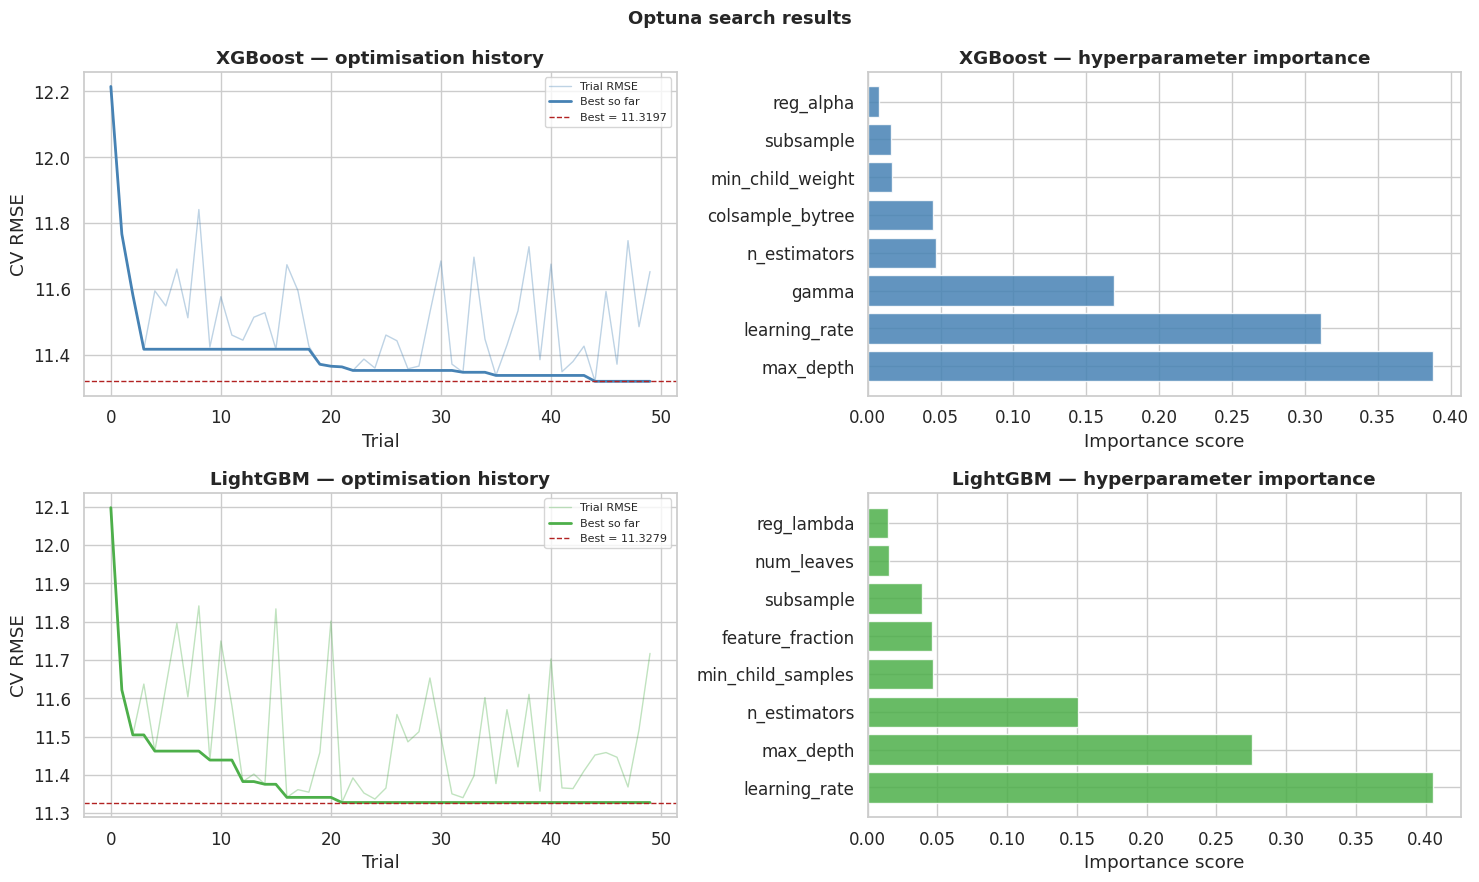

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for row, (study, label, color) in enumerate([
    (xgb_study, 'XGBoost',  'steelblue'),
    (lgb_study, 'LightGBM', '#4daf4a'),
]):
    vals       = [t.value for t in study.trials if t.value is not None]
    best_curve = np.minimum.accumulate(vals)

    # History
    axes[row, 0].plot(vals, alpha=0.35, color=color, lw=1, label='Trial RMSE')
    axes[row, 0].plot(best_curve, color=color, lw=2,   label='Best so far')
    axes[row, 0].axhline(min(vals), color='firebrick', lw=1, ls='--',
                          label=f'Best = {min(vals):.4f}')
    axes[row, 0].set_xlabel('Trial'); axes[row, 0].set_ylabel('CV RMSE')
    axes[row, 0].set_title(f'{label} — optimisation history', fontweight='bold')
    axes[row, 0].legend(fontsize=8)

    # Param importance
    imp  = optuna.importance.get_param_importances(study)
    top  = sorted(imp.items(), key=lambda x: x[1], reverse=True)[:8]
    axes[row, 1].barh([k for k, v in top], [v for k, v in top],
                       color=color, alpha=0.85)
    axes[row, 1].set_xlabel('Importance score')
    axes[row, 1].set_title(f'{label} — hyperparameter importance', fontweight='bold')

plt.suptitle('Optuna search results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5 · Model Comparison

2×2 grid: {XGBoost, LightGBM} × {all\_37, extended}.  
XGBoost uses `device=XGB_DEVICE` (GPU if ROCm detected). LightGBM runs CPU only (PyPI wheel).  

**To add a new experiment:** add `('model_type', 'feat_key')` to `EXPERIMENTS` and a matching entry to `FEATURE_SETS` if using a new feature set, then re-run this cell.

In [7]:
FEATURE_SETS = {
    'all_37':   (ALL_FEATURES,      df_train,     df_val,     df_holdout),
    'extended': (EXTENDED_FEATURES, df_train_ext, df_val_ext, df_holdout_ext),
}

EXPERIMENTS = [
    ('xgb', 'all_37'),
    ('xgb', 'extended'),
    ('lgb', 'all_37'),
    ('lgb', 'extended'),
]

def run_experiment(model_type, feat_key):
    feats, df_tr, df_va, df_ho = FEATURE_SETS[feat_key]
    Xfull = np.vstack([df_tr[feats].values, df_va[feats].values])
    yfull = np.concatenate([y_train, y_val])

    if model_type == 'xgb':
        m = xgb.XGBRegressor(**best_xgb, device=XGB_DEVICE, random_state=42, n_jobs=-1)
    else:
        m = lgb.LGBMRegressor(**best_lgb, random_state=42, n_jobs=-1, verbose=-1)
    m.fit(Xfull, yfull)

    preds = np.asarray(m.predict(df_ho[feats].values), dtype=float)
    return {
        'name':       f'{model_type}_{feat_key}',
        'model_type': model_type,
        'feat_key':   feat_key,
        'n_features': len(feats),
        'rmse':  float(np.sqrt(mean_squared_error(y_holdout, preds))),
        'mae':   float(mean_absolute_error(y_holdout, preds)),
        'nasa':  float(nasa_score(y_holdout, preds)),
        'bias':  float(np.mean(preds - y_holdout)),
        'model': m,
        'feats': feats,
        'df_ho': df_ho,
    }

print(f'Running {len(EXPERIMENTS)} experiments (XGB device={XGB_DEVICE})...\n')
exp_results = []
for mtype, fkey in EXPERIMENTS:
    r = run_experiment(mtype, fkey)
    exp_results.append(r)
    print(f"  {r['name']:<22s} ({r['n_features']:2d} feats)  "
          f"RMSE={r['rmse']:6.2f}  MAE={r['mae']:6.2f}  "
          f"NASA={r['nasa']:10.1f}  bias={r['bias']:+.2f}")

# ── Leaderboard ──────────────────────────────────────────────────────────────
leaderboard = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('model', 'feats', 'df_ho')}
     for r in exp_results]
).sort_values('rmse').reset_index(drop=True)

print('\n=== Leaderboard (sorted by RMSE) ===')
print(leaderboard.to_string(index=False))

# Correct winner lookup: find by name, not by leaderboard integer index
# (after reset_index, index[0] is always 0 — does NOT index into exp_results)
winner_name = leaderboard.iloc[0]['name']
winner = next(r for r in exp_results if r['name'] == winner_name)
print(f"\nWinner: {winner['name']}  "
      f"RMSE={winner['rmse']:.2f}  MAE={winner['mae']:.2f}  NASA={winner['nasa']:.1f}")


Running 4 experiments (XGB device=cuda)...

  xgb_all_37             (37 feats)  RMSE= 11.02  MAE=  6.82  NASA=   17677.1  bias=+1.20
  xgb_extended           (51 feats)  RMSE= 10.96  MAE=  6.66  NASA=   17719.4  bias=+1.17
  lgb_all_37             (37 feats)  RMSE= 10.95  MAE=  6.82  NASA=   17187.0  bias=+1.21
  lgb_extended           (51 feats)  RMSE= 10.90  MAE=  6.70  NASA=   17139.8  bias=+1.17

=== Leaderboard (sorted by RMSE) ===
        name model_type feat_key  n_features    rmse    mae       nasa   bias
lgb_extended        lgb extended          51 10.8997 6.6995 17139.8138 1.1687
  lgb_all_37        lgb   all_37          37 10.9501 6.8208 17186.9666 1.2094
xgb_extended        xgb extended          51 10.9553 6.6637 17719.4323 1.1665
  xgb_all_37        xgb   all_37          37 11.0248 6.8190 17677.0924 1.1969

Winner: lgb_extended  RMSE=10.90  MAE=6.70  NASA=17139.8


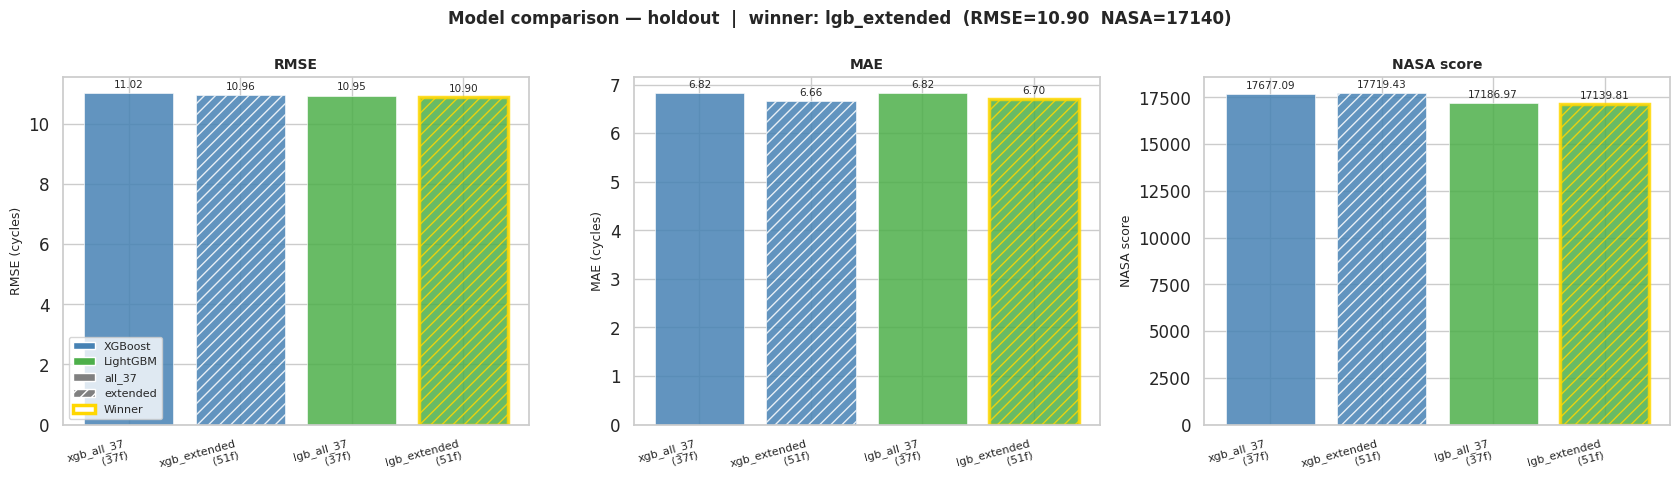

In [8]:
from matplotlib.patches import Patch

TYPE_COLOR = {'xgb': 'steelblue', 'lgb': '#4daf4a'}
FEAT_HATCH = {'all_37': '', 'extended': '///'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = np.arange(len(exp_results))

for ax, key, ylabel, title in [
    (axes[0], 'rmse', 'RMSE (cycles)',  'RMSE'),
    (axes[1], 'mae',  'MAE (cycles)',   'MAE'),
    (axes[2], 'nasa', 'NASA score',     'NASA score'),
]:
    for xi, r in enumerate(exp_results):
        is_winner = r['name'] == winner['name']
        ax.bar(xi, r[key],
               color=TYPE_COLOR[r['model_type']],
               hatch=FEAT_HATCH[r['feat_key']],
               alpha=0.85,
               edgecolor='gold' if is_winner else 'white',
               linewidth=2.5  if is_winner else 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['name']}\n({r['n_features']}f)" for r in exp_results],
        fontsize=8, rotation=15, ha='right')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    vals = [r[key] for r in exp_results]
    for xi, v in enumerate(vals):
        ax.text(xi, v * 1.01, f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)

axes[0].legend(handles=[
    Patch(facecolor='steelblue', label='XGBoost'),
    Patch(facecolor='#4daf4a',   label='LightGBM'),
    Patch(facecolor='grey', hatch='',    label='all_37'),
    Patch(facecolor='grey', hatch='///', label='extended'),
    Patch(facecolor='white', edgecolor='gold', linewidth=2.5, label='Winner'),
], fontsize=8)

plt.suptitle(f'Model comparison — holdout  |  winner: {winner["name"]}  '  
             f'(RMSE={winner["rmse"]:.2f}  NASA={winner["nasa"]:.0f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6 · Winner Analysis

All plots and metrics below are driven entirely by `winner` — they update automatically if the leaderboard changes.

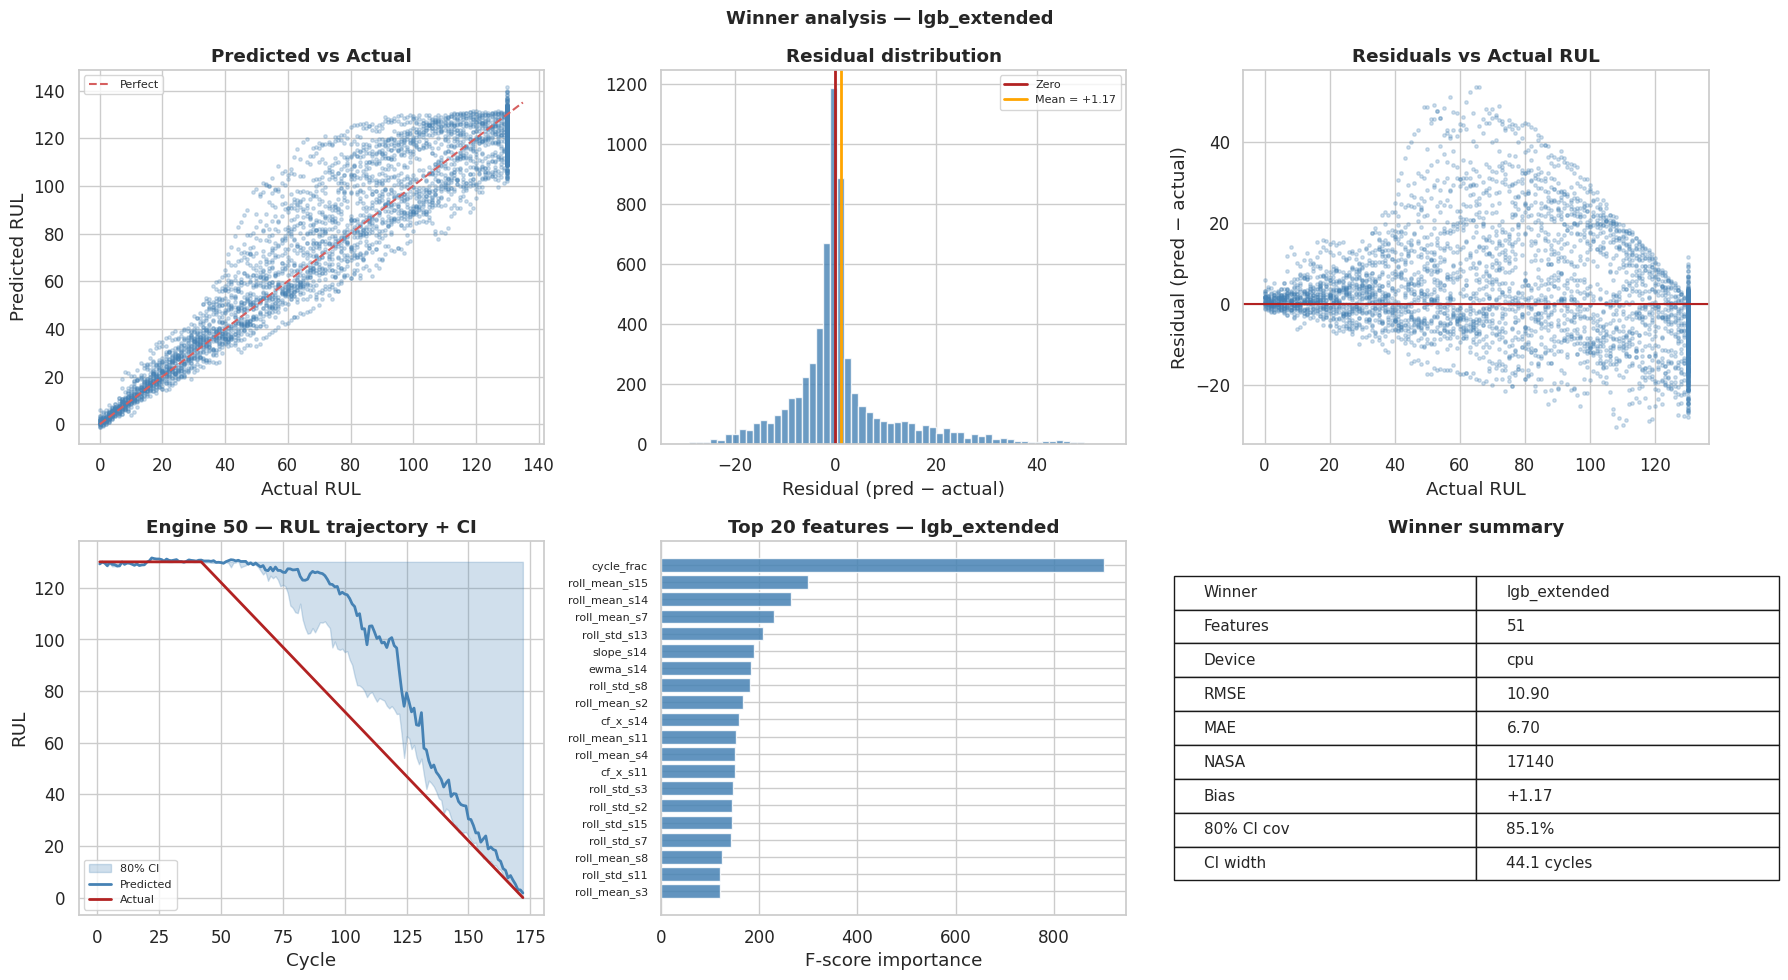

80% CI coverage: 85.1%  |  avg width: 44.1 cycles


In [9]:
w_model = winner['model']
w_feats = winner['feats']
w_df_ho = winner['df_ho']
w_mtype = winner['model_type']

preds_hold = np.asarray(w_model.predict(w_df_ho[w_feats].values), dtype=float)
residuals  = preds_hold - y_holdout

# Quantile bounds fitted on the same feature set as the winner
_, df_tr_w, df_va_w, _ = FEATURE_SETS[winner['feat_key']]
Xfull_w = np.vstack([df_tr_w[w_feats].values, df_va_w[w_feats].values])
yfull_w  = np.concatenate([y_train, y_val])

if w_mtype == 'xgb':
    q_lo = xgb.XGBRegressor(**best_xgb, device=XGB_DEVICE, random_state=42, n_jobs=-1,
                              objective='reg:quantileerror', quantile_alpha=0.10)
    q_hi = xgb.XGBRegressor(**best_xgb, device=XGB_DEVICE, random_state=42, n_jobs=-1,
                              objective='reg:quantileerror', quantile_alpha=0.90)
else:
    q_lo = lgb.LGBMRegressor(**best_lgb, objective='quantile', alpha=0.10,
                               random_state=42, n_jobs=-1, verbose=-1)
    q_hi = lgb.LGBMRegressor(**best_lgb, objective='quantile', alpha=0.90,
                               random_state=42, n_jobs=-1, verbose=-1)
q_lo.fit(Xfull_w, yfull_w)
q_hi.fit(Xfull_w, yfull_w)

ci_lo    = np.asarray(q_lo.predict(w_df_ho[w_feats].values), dtype=float)
ci_hi    = np.asarray(q_hi.predict(w_df_ho[w_feats].values), dtype=float)
ci_cov   = float(np.mean((y_holdout >= ci_lo) & (y_holdout <= ci_hi)))
ci_width = float(np.mean(ci_hi - ci_lo))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 – Predicted vs actual
axes[0,0].scatter(y_holdout, preds_hold, alpha=0.25, s=6, color='steelblue')
axes[0,0].plot([0, RUL_CAP+5], [0, RUL_CAP+5], 'r--', lw=1.5, label='Perfect')
axes[0,0].set_xlabel('Actual RUL'); axes[0,0].set_ylabel('Predicted RUL')
axes[0,0].set_title('Predicted vs Actual', fontweight='bold')
axes[0,0].legend(fontsize=8)

# 2 – Residual distribution
axes[0,1].hist(residuals, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0,1].axvline(0,               color='firebrick', lw=2, label='Zero')
axes[0,1].axvline(residuals.mean(),color='orange',    lw=2,
                  label=f'Mean = {residuals.mean():+.2f}')
axes[0,1].set_xlabel('Residual (pred − actual)')
axes[0,1].set_title('Residual distribution', fontweight='bold')
axes[0,1].legend(fontsize=8)

# 3 – Residuals vs actual RUL (heteroscedasticity check)
axes[0,2].scatter(y_holdout, residuals, alpha=0.25, s=6, color='steelblue')
axes[0,2].axhline(0, color='firebrick', lw=1.5)
axes[0,2].set_xlabel('Actual RUL'); axes[0,2].set_ylabel('Residual (pred − actual)')
axes[0,2].set_title('Residuals vs Actual RUL', fontweight='bold')

# 4 – CI ribbon on a sample engine
sample_unit = holdout_units[0]
mask        = w_df_ho['unit'] == sample_unit
eng_cycles  = w_df_ho.loc[mask, 'cycle'].values
eng_X       = w_df_ho.loc[mask, w_feats].values
eng_y       = y_holdout[w_df_ho['unit'].values == sample_unit]
axes[1,0].fill_between(eng_cycles, q_lo.predict(eng_X), q_hi.predict(eng_X),
                        alpha=0.25, color='steelblue', label='80% CI')
axes[1,0].plot(eng_cycles, w_model.predict(eng_X), color='steelblue', lw=2, label='Predicted')
axes[1,0].plot(eng_cycles, eng_y,                  color='firebrick',  lw=2, label='Actual')
axes[1,0].set_xlabel('Cycle'); axes[1,0].set_ylabel('RUL')
axes[1,0].set_title(f'Engine {sample_unit} — RUL trajectory + CI', fontweight='bold')
axes[1,0].legend(fontsize=8)

# 5 – Feature importance top 20
imp = pd.Series(w_model.feature_importances_, index=w_feats)\
         .sort_values(ascending=False).head(20)
axes[1,1].barh(range(len(imp)), imp.values[::-1], color='steelblue', alpha=0.85)
axes[1,1].set_yticks(range(len(imp)))
axes[1,1].set_yticklabels(imp.index[::-1], fontsize=8)
axes[1,1].set_xlabel('F-score importance')
axes[1,1].set_title(f'Top 20 features — {winner["name"]}', fontweight='bold')

# 6 – Score card
axes[1,2].axis('off')
tbl_data = [
    ['Winner',     winner['name']],
    ['Features',   str(winner['n_features'])],
    ['Device',     XGB_DEVICE if w_mtype == 'xgb' else 'cpu'],
    ['RMSE',       f"{winner['rmse']:.2f}"],
    ['MAE',        f"{winner['mae']:.2f}"],
    ['NASA',       f"{winner['nasa']:.0f}"],
    ['Bias',       f"{winner['bias']:+.2f}"],
    ['80% CI cov', f"{ci_cov:.1%}"],
    ['CI width',   f"{ci_width:.1f} cycles"],
]
tbl = axes[1,2].table(cellText=tbl_data, loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 1.9)
axes[1,2].set_title(f'Winner summary', fontweight='bold')

plt.suptitle(f'Winner analysis — {winner["name"]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'80% CI coverage: {ci_cov:.1%}  |  avg width: {ci_width:.1f} cycles')


## 7 · Save Best Model Artefacts

In [ ]:
joblib.dump(winner['model'], RUL_DIR / 'rul_model.pkl')
joblib.dump(q_lo,            RUL_DIR / 'rul_model_lower.pkl')
joblib.dump(q_hi,            RUL_DIR / 'rul_model_upper.pkl')
joblib.dump({
    'experiment':   winner['name'],
    'model_type':   winner['model_type'],
    'feature_set':  winner['feat_key'],
    'features':     winner['feats'],
    'best_params':  best_xgb if winner['model_type'] == 'xgb' else best_lgb,
    'holdout_rmse': winner['rmse'],
    'holdout_mae':  winner['mae'],
    'holdout_nasa': winner['nasa'],
    'holdout_bias': winner['bias'],
    'ci_coverage':  ci_cov,
    'ci_avg_width': ci_width,
    'xgb_device':   XGB_DEVICE,
    'train_units':  train_units.tolist(),
    'val_units':    val_units.tolist(),
    'holdout_units':holdout_units.tolist(),
}, RUL_DIR / 'rul_meta.pkl')

print(f'Winner          : {winner["name"]}')
print(f'Feature set     : {winner["feat_key"]}  ({winner["n_features"]} features)')
print(f'Holdout RMSE    : {winner["rmse"]:.2f}')
print(f'Holdout MAE     : {winner["mae"]:.2f}')
print(f'Holdout NASA    : {winner["nasa"]:.1f}')
print(f'Holdout bias    : {winner["bias"]:+.2f}')
print(f'80% CI coverage : {ci_cov:.1%}  (avg width {ci_width:.1f} cycles)')
print(f'XGB device      : {XGB_DEVICE}')
print()
for fname in ['rul_model.pkl','rul_model_lower.pkl','rul_model_upper.pkl','rul_meta.pkl']:
    p = RUL_DIR / fname
    print(f'  {fname:<38s} {p.stat().st_size/1024:.0f} KB')

Winner          : lgb_extended
Feature set     : extended  (51 features)
Holdout RMSE    : 10.90
Holdout MAE     : 6.70
Holdout NASA    : 17139.8
Holdout bias    : +1.17
80% CI coverage : 85.1%  (avg width 44.1 cycles)
XGB device      : cuda

  rul_model.pkl                          626 KB
  rul_model_lower.pkl                    597 KB
  rul_model_upper.pkl                    7 KB
  rul_meta.pkl                           2 KB


## Summary

| | |
|---|---|
| Models | XGBoost (ROCm GPU via HIP if detected), LightGBM (CPU — PyPI wheel) |
| Feature sets | all\_37 (base) · extended (all\_37 + 14: EWMA, interactions, fleet-relative, acceleration) |
| Split | 80/10/10 by engine unit — no row-level leakage |
| Tuning | Optuna TPE, 50 trials × 5-fold unit-aware CV, run independently per model family |
| CI | Quantile regression 10th/90th percentile for 80% bound, fitted on winner feature set |
| Analysis | All residual/importance plots driven by `winner` — auto-updates if leaderboard changes |

**To extend:** add `('model_type', 'feat_key')` to `EXPERIMENTS` in section 5 and a matching `FEATURE_SETS` entry if using a new feature set.

**Next →** [05_gru_model.ipynb](05_gru_model.ipynb) — GRU training and evaluation.